In [1]:
import sys

import importlib
import numpy as np
import os

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

# Import du module de chargement des données
module_name = "RSA_deep_working.Data_loader.class_data_loaders"

try:
    class_data_loaders = importlib.import_module(module_name)
    DirectoryRSAClass = class_data_loaders.DirectoryRSAClass
except ModuleNotFoundError as e:
    print(f"Erreur lors de l'importation du module {module_name} : {e}")
    sys.exit(1)

Chemin du projet : /home/loai/Documents/code/RSMLExtraction


In [2]:

import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm

# set python path to the project root
#sys.path.append("/home/loai/Documents/code/RSMLExtraction/")
from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass

# importing pretrained segmentation model
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter


2025-04-07 13:19:36.770057: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-07 13:19:36.780294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744024776.792244  220043 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744024776.795831  220043 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744024776.805002  220043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Dataset and data loaders

In [3]:
base_directory = "/home/loai/Images/DataTest/UC1_data"

In [4]:
from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass
import os
import numpy as np
import tifffile
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

# Dimensions d'origine et calculs
H, W = (1166, 1348)

H_new, W_new = (1024, 1024)
padding_bottom, padding_right = H_new - H, W_new - W  # the opposite lol
print("pad :", padding_right, padding_bottom)

# Transformations pré-calculées
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.BILINEAR),
    #transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
mask_transform_series = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
    #transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),

])
mask_transform_image = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new // 2, W_new // 2), interpolation=transforms.InterpolationMode.NEAREST),
    #transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),
])


def mtg_transform(mtg):
    """
    Transforme le MTG en un tenseur PyTorch.
    """
    # Convertir le MTG en une représentation adaptée
    # Par exemple, convertir les coordonnées en tenseur
    # ou appliquer d'autres transformations spécifiques
    return mtg

pad : -324 -142


In [ ]:
# Optimisation de la lecture des TIFF : mise en cache par fichier
class CachedTiffReader:
    def __init__(self):
        self.cache = {}

    def get_page(self, img_path, key):
        if img_path not in self.cache:
            # Chargement unique du fichier, stockage de toutes les pages
            with tifffile.TiffFile(img_path) as tif:
                self.cache[img_path] = [page.asarray() for page in tif.pages]
        return self.cache[img_path][key]


tiff_reader = CachedTiffReader()


class RSASeg2DDataset(Dataset):
    def __init__(self, rsa_dir_loader, mode='series', img_transform=None,
                 mask_transform_series=None, mask_transform_image=None, image_with_mtg=False, as_RGB=False):
        """
        mode: 'series' pour charger l'ensemble de la série temporelle,
              'image' pour charger image par image.
        """
        self.mode = mode
        self.samples = []  # contiendra les tuples en fonction du mode
        self.img_transform = img_transform
        self.mask_transform_series = mask_transform_series
        self.mask_transform_image = mask_transform_image
        self.image_with_mtg = image_with_mtg
        self.as_RGB = as_RGB

        for loader in rsa_dir_loader.loaders:
            img_path = loader.image_stack_path
            mask_path = loader.date_map_path
            mtg_path = loader.rsml_default_file if os.path.exists(loader.rsml_default_file) else loader.rsml_expert_file

            # Lecture du nombre de slices dans la série
            with tifffile.TiffFile(img_path) as tif:
                num_slices = len(tif.pages)

            if mode == 'series':
                # Une entrée par série temporelle complète, on stocke num_slices
                self.samples.append((img_path, mask_path, num_slices, mtg_path))
            elif mode == 'image':
                # Une entrée par image (slice)
                for z in range(num_slices):
                    self.samples.append((img_path, mask_path, z, mtg_path))
            else:
                raise ValueError("Mode non reconnu, choisissez 'series' ou 'image'")

    def __len__(self):
        return len(self.samples)

    def num_times(self, idx):
        """
        Retourne le nombre de slices (temps) que comporte la série.
        """
        img_path, _, _, _ = self.samples[idx]
        with tifffile.TiffFile(img_path) as tif:
            num_slices = len(tif.pages)
        return num_slices

    def __getitem__(self, idx):
        # Extraction des informations de l'échantillon
        img_path, mask_path, slice_info, mtg_path = self.samples[idx]

        if self.mode == 'series':
            # Mode série : chargement complet de la série d'images
            img = tifffile.imread(img_path)
            mask_raw = tifffile.imread(mask_path)
            extra_info = slice_info  # ici, slice_info correspond à num_slices

            if self.img_transform:
                img = self.img_transform(img)
            # Appliquer la transformation du masque ou utiliser le masque brut
            mask = self.mask_transform_series(mask_raw) if self.mask_transform_series else mask_raw

        else:  # mode 'image'
            # Mode image : slice_info correspond à l'index de la slice (z)
            z = slice_info
            img = tiff_reader.get_page(img_path, z)
            mask_raw = tifffile.imread(mask_path)
            extra_info = z

            # Calcul vectorisé du masque : les pixels non nuls et <= z valent 1, sinon 0
            mask = np.where((mask_raw != 0) & (mask_raw <= z + 1), 1, 0)

            if self.img_transform:
                img = self.img_transform(img)
            mask = self.mask_transform_image(mask) if self.mask_transform_image else mask

        if (self.as_RGB):
            img = img.repeat(3, 1, 1)
        # Gestion du retour : si image_with_mtg est activé, on retourne mtg_path, sinon un tensor nul
        additional = mtg_path if self.image_with_mtg else torch.tensor(0)
        return img, mask, extra_info, additional


In [6]:

dir_loader = DirectoryRSAClass(base_directory, load_date_map=True, lazy=True)

# Pour entraîner image par image :
rsa_dataset_image = RSASeg2DDataset(
    dir_loader,
    mode='image',
    img_transform=img_transform,
    mask_transform_image=mask_transform_image,  # pipeline dédié
    image_with_mtg=True,
    as_RGB=True)

print("Nombre d'échantillons :", len(rsa_dataset_image), "images\n")

# for reproducibility
torch.manual_seed(42)
np.random.seed(42)

generator = torch.Generator().manual_seed(42)

train_set, val_set, test_set = torch.utils.data.random_split(
    rsa_dataset_image,
    [int(len(rsa_dataset_image) * 0.7), int(len(rsa_dataset_image) * 0.2),
     int(len(rsa_dataset_image) * 0.1) + 2],
    generator=generator
)

# Affichage des tailles des ensembles
print("Ensemble d'entraînement (image) :", len(train_set))
print("Ensemble de validation (image) :", len(val_set))
print("Ensemble de test (image) :", len(test_set))

Nombre d'échantillons : 754 images

Ensemble d'entraînement (image) : 527
Ensemble de validation (image) : 150
Ensemble de test (image) : 77


### 2D Image loaders

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

BATCH_SIZE = 6
# data loader optimization
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=8,
                                           pin_memory=True,
                                           worker_init_fn=lambda worker_id: np.random.seed(42 + worker_id))
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True,
                                         worker_init_fn=lambda worker_id: np.random.seed(42 + worker_id))
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=8,
                                          pin_memory=True,
                                          worker_init_fn=lambda worker_id: np.random.seed(42 + worker_id))

Utilisation du device : cuda


## Evaluation

In [8]:
import io
from PIL import Image


def tensor_to_heatmap_image(tensor, cmap='hot'):
    """
    Convertit un tableau numpy 2D en image heatmap.
    """
    plt.figure()
    plt.imshow(tensor, cmap=cmap)
    plt.axis('off')
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close()
    buf.seek(0)
    image = Image.open(buf)
    image = image.convert("RGB")
    return image

In [9]:
# =============================================================================
# Fonction utilitaire pour créer une image heatmap à partir d'un tenseur
# =============================================================================
def tensor_to_heatmap_image(tensor, cmap='hot'):
    plt.figure()
    plt.imshow(tensor, cmap=cmap)
    plt.axis('off')
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close()
    buf.seek(0)
    image = Image.open(buf)
    return image.convert("RGB")


# =============================================================================
# Fonctions d'évaluation
# =============================================================================

def evaluate_segmentation(model, image, mask, mtg, metrics: list, prediction=None, threshold=0.5, writer=None,
                          global_step=None, device='cpu'):
    """
    Évalue le modèle sur une image (ou un batch d'images) et calcule les métriques fournies.
    """
    model.eval()
    image = image.to(device)
    mask = mask.to(device)

    # Calcul de la prédiction si non fournie
    if prediction is None:
        with torch.no_grad():
            output = model(image)
            pred = torch.sigmoid(output)
            prediction = (pred > threshold).float()

    scores = {}
    for metric in metrics:
        scores[metric.__name__] = metric(prediction, mask, mtg=mtg)

    # Log des résultats dans TensorBoard si le writer est fourni
    if writer is not None and global_step is not None:
        for metric_name, score in scores.items():
            writer.add_scalar(f"Eval/{metric_name}", score, global_step)

    return {'prediction': prediction, 'scores': scores}


def evaluate_segmentation_on_loader(model, loader, metrics: list, threshold=0.5, writer=None, global_step=None,
                                    device='cpu'):
    """
    Évalue le modèle sur un DataLoader complet et accumule les scores pour chaque métrique.
    """
    model.eval()
    metric_scores = {metric.__name__: [] for metric in metrics}
    all_predictions = []
    all_masks = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluation iteration", dynamic_ncols=True):
            images, masks, time, mtgs = batch
            images = images.to(device)
            masks = masks.to(device)
            print("images shape :", type(images))
            print("images shape :", images.shape)

            output = model(images)[0]

            print("output shape :", type(output))
            print("output shape :", output.shape)
            # merge all 6 channels
            output = torch.mean(output, dim=1)
            pred = torch.sigmoid(output)
            prediction = (pred > threshold).float()

            # Calculer et accumuler les scores pour chaque métrique
            for metric in metrics:
                score = metric(prediction, masks, time, mtg=mtgs[0])
                metric_scores[metric.__name__].append(score)

            all_predictions.append(prediction.cpu())
            all_masks.append(masks.cpu())

    # Calcul de la moyenne sur l'ensemble des batches de tout le DataLoader
    final_scores = {name: np.mean(scores) for name, scores in metric_scores.items()}

    if writer is not None and global_step is not None:
        for metric_name, score in final_scores.items():
            writer.add_scalar(f"Eval/{metric_name}", score, global_step)

    return {
        'scores': final_scores,
        'predictions': torch.cat(all_predictions),
        'masks': torch.cat(all_masks)
    }

In [10]:
import RSA_deep_working.Metrics.simple_metrics as sm
import RSA_deep_working.Metrics.topo_explicit_metrics as tm

metrics = sm.all_metrics()
tubular_metrics = tm.all_metrics()
all_metrics = []
for metric in metrics:
    all_metrics.append(metric)
for metric in tubular_metrics:
    all_metrics.append(metric)

In [11]:
print("Nombre de métriques :", len(all_metrics))
import pprint

pprint.pprint([metric.__name__ for metric in all_metrics])

Nombre de métriques : 17
['dice',
 'f1_score',
 'iou',
 'pixel_accuracy',
 'precision',
 'recall',
 'specificity',
 'connectivity_metric',
 'ARI_index',
 'VI_index',
 'ARE_error',
 'betti_0_difference',
 'euler_charac_difference',
 'cldice',
 'skeleton_recall',
 'Connectivity_Preserving_Instance_Segmentation',
 'evaluate_sk_seg']


## Model

Loading model...Done
Shape de la sortie : torch.Size([6, 256, 256])


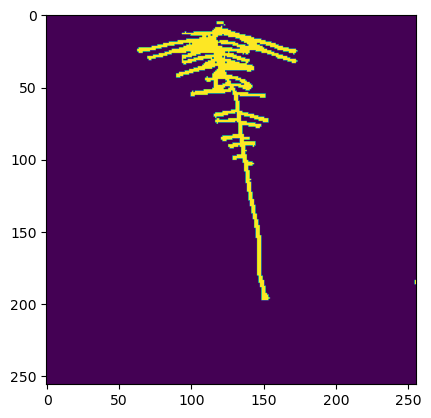

In [31]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms


def mask_4_RootNav(output_of_model, threshold=0.7):
    # get channels 1 to 5 avoid 0 
    mask = output_of_model[1:6]
    # apply threshold
    mask = (mask > threshold).float()
    # merge the channels
    mask = torch.mean(mask, dim=0)
    # convert to binary
    mask = (mask > 0).float()
    # convert to uint8
    mask = mask.cpu().numpy().astype(np.uint8)
    # convert to PIL image
    mask = Image.fromarray(mask * 255, mode='L')
    return mask


# Définition du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Exemple de transformation sur l'image (adapter selon votre modèle)
img_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

# Chargement du modèle
# Remplacer par votre code d'initialisation du modèle
from RSA_deep_working.Existing_models.RootNav2.inference.models import ModelLoader

Rootnav2 = ModelLoader.get_model("wheat_bluepaper", gpu=torch.cuda.is_available())
Rootnav2_Model = Rootnav2['model']
Rootnav2_Model.to(device)

# Chargement et préparation de l'image
path_image = "/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Existing_models/RootNav2/training/OSR_Root_dataset/test/C_osr_0129.jpg"  # Modifiez ce chemin selon vos données
image = Image.open(path_image)
image = img_transform(image)
image = image.unsqueeze(0)  # Ajout de la dimension batch
image = image.to(device)

# Passage en mode évaluation
Rootnav2_Model.eval()
with torch.no_grad():
    # Exécution du modèle
    output = Rootnav2_Model(image)[-1]

    output = output.squeeze(0)  # Suppression de la dimension batch
    mask = mask_4_RootNav(output)
    # Affichage de la forme attendue [6, 512, 512]
    print("Shape de la sortie :", output.shape)
    plt.imshow(mask)

    plt.show()





In [ ]:
# Définition du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Exemple de transformation sur l'image (adapter selon votre modèle)
img_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

# Chargement du modèle
# Remplacer par votre code d'initialisation du modèle
from RSA_deep_working.Existing_models.RootNav2.inference.models import ModelLoader

Rootnav2 = ModelLoader.get_model("wheat_bluepaper", gpu=torch.cuda.is_available())
Rootnav2_Model = Rootnav2['model']
Rootnav2_Model.to(device)

# Chargement et préparation de l'image
path_image = "/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Existing_models/RootNav2/training/OSR_Root_dataset/test/C_osr_0129.jpg"  # Modifiez ce chemin selon vos données
image = Image.open(path_image)
image = img_transform(image)
image = image.unsqueeze(0)  # Ajout de la dimension batch
image = image.to(device)

# Passage en mode évaluation
Rootnav2_Model.eval()
with torch.no_grad():
    # Exécution du modèle
    output = Rootnav2_Model(image)[-1]

    output = output.squeeze(0)  # Suppression de la dimension batch
    mask = mask_4_RootNav(output)
    # Affichage de la forme attendue [6, 512, 512]
    print("Shape de la sortie :", output.shape)
    plt.imshow(mask)

    plt.show()





Loading model...Done
Shape de la sortie : torch.Size([6, 512, 512])


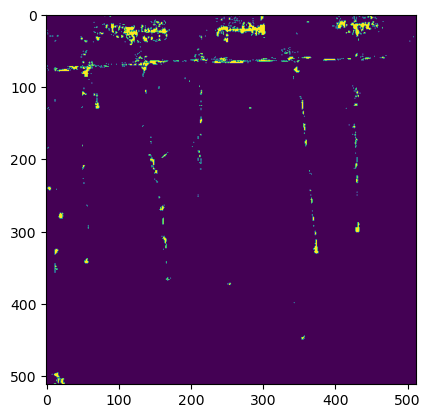

In [33]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Définition du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Exemple de transformation sur l'image (adapter selon votre modèle)
img_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

# Chargement du modèle
# Remplacer par votre code d'initialisation du modèle
from RSA_deep_working.Existing_models.RootNav2.inference.models import ModelLoader

Rootnav2 = ModelLoader.get_model("wheat_bluepaper", gpu=torch.cuda.is_available())
Rootnav2_Model = Rootnav2['model']
Rootnav2_Model.to(device)

# Chargement et préparation de l'image
image, mask, time, mtg = rsa_dataset_image[-1]
image = image.unsqueeze(0)  # Ajout de la dimension batch
image = image.to(device)

# Passage en mode évaluation
Rootnav2_Model.eval()
with torch.no_grad():
    # Exécution du modèle
    output = Rootnav2_Model(image)[-1]

    output = output.squeeze(0)  # Suppression de la dimension batch
    mask = mask_4_RootNav(output)
    # Affichage de la forme attendue [6, 512, 512]
    print("Shape de la sortie :", output.shape)
    plt.imshow(mask)

    plt.show()





Loading model...Done
Shape de la sortie : torch.Size([1, 6, 512, 512])


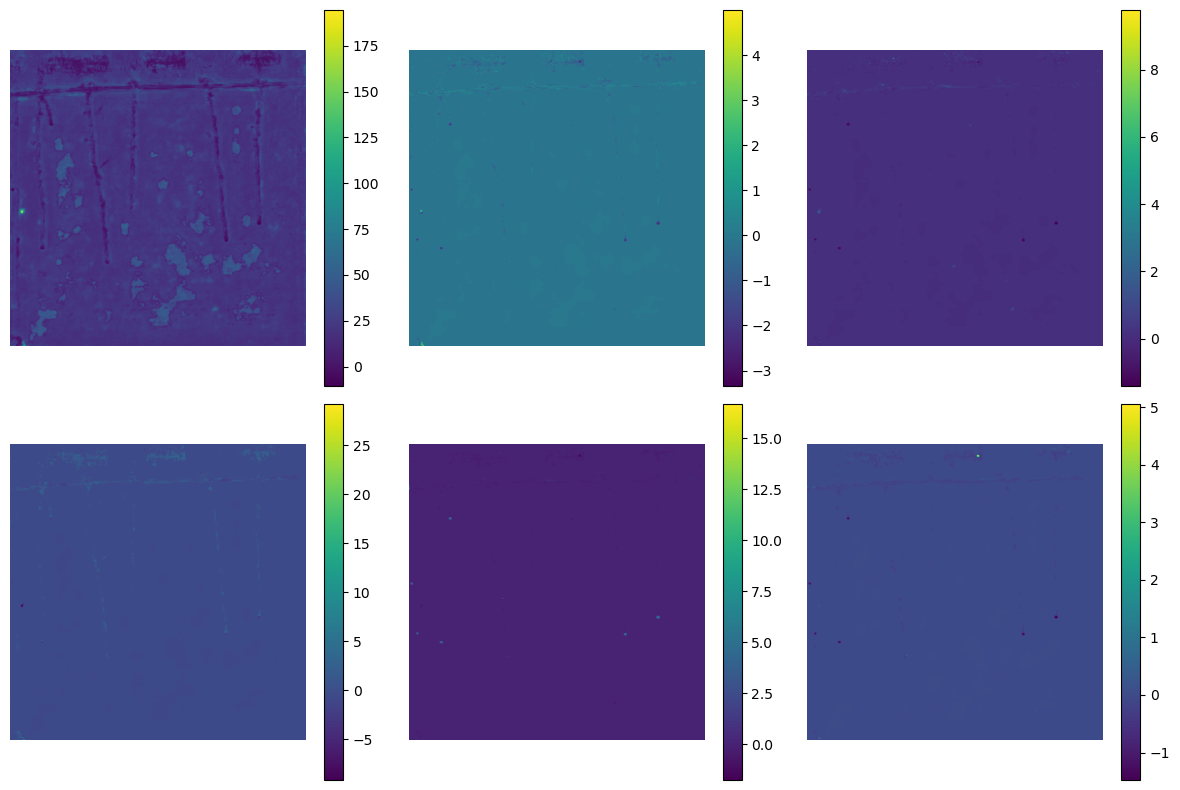

In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Définition du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Exemple de transformation sur l'image (adapter selon votre modèle)
img_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

# Chargement du modèle
# Remplacer par votre code d'initialisation du modèle
from RSA_deep_working.Existing_models.RootNav2.inference.models import ModelLoader

Rootnav2 = ModelLoader.get_model("wheat_bluepaper", gpu=torch.cuda.is_available())
Rootnav2_Model = Rootnav2['model']
Rootnav2_Model.to(device)

# Chargement et préparation de l'image
image, mask, time, mtg = rsa_dataset_image[-1]
image = image.unsqueeze(0)  # Ajout de la dimension batch
image = image.to(device)

# Passage en mode évaluation
Rootnav2_Model.eval()
with torch.no_grad():
    # Exécution du modèle
    output = Rootnav2_Model(image)

    # Si le modèle renvoie une liste, on récupère le premier élément
    output = output[0]
    # Affichage de la forme attendue [6, 512, 512]
    print("Shape de la sortie :", output.shape)
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    for i in range(6):
        ax[i // 3, i % 3].imshow(output[0][i].cpu().numpy())
        ax[i // 3, i % 3].axis('off')
        plt.colorbar(ax[i // 3, i % 3].imshow(output[0][i].cpu().numpy()), ax=ax[i // 3, i % 3])
    plt.tight_layout()

    plt.show()

## Training

In [13]:
# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu', writer=None):
    torch.cuda.empty_cache()
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", position=0, leave=True,
                          dynamic_ncols=True):
            images, masks, _, _ = batch
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        #print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
        torch.cuda.empty_cache()

        # Log the loss to TensorBoard
        if writer is not None:
            writer.add_scalar("Loss/train", epoch_loss, epoch)

        # Evaluation on validation set
        if val_loader is not None:
            evaluate_segmentation_on_loader(
                model,
                val_loader,
                metrics=all_metrics,
                threshold=0.5,
                writer=writer,
                global_step=epoch,
                device=device
            )
        torch.cuda.empty_cache()

    return model

In [14]:
# cuda - clear cache
torch.cuda.empty_cache()

In [15]:
# adam optimizer with weight decay for each model
def get_optimizer(model, lr=5e-5, weight_decay=1e-6):
    return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


optimizers = []
for model in List_models:
    optimizers.append(get_optimizer(model))

NameError: name 'List_models' is not defined

In [ ]:
def cldice(prediction, mask, time=0, mtg=None):
    """
    Custom clDice loss function.
    """
    return 1 - tm.cldice(prediction, mask, time, mtg)


def bce(prediction, mask, time=0, mtg=None):
    """
    Binary Cross Entropy loss function.
    """
    return F.binary_cross_entropy_with_logits(prediction, mask)


def dice(prediction, mask, time=0, mtg=None):
    """
    Dice loss function.
    """
    return smp.losses.DiceLoss(mode='binary')(prediction, mask)


def dice_cldice(prediction, mask, time=0, mtg=None):
    """
    Combined Dice and clDice loss function.
    """
    return 0.5 * smp.losses.DiceLoss(mode='binary')(prediction, mask) + 0.5 * cldice(prediction, mask, time, mtg)


# list of loss functions corresponding to the models
loss_functions = [
    bce,
    dice,
    cldice,
    dice_cldice,
    tm.skeleton_recall,
    tm.Connectivity_Preserving_Instance_Segmentation,
    tm.evaluate_sk_seg,
]

In [ ]:
# one writer for each model
writers = []
writer_names = [
    "BCE",
    "Dice",
    "clDice",
    "Dice_clDice",
    "skRecall",
    "superVoxel",
    "skseg"
]
for i in range(len(loss_functions)):
    writer = SummaryWriter(f"runs/model_{writer_names[i]}")
    writers.append(writer)
global_steps = [0] * len(loss_functions)

In [ ]:
def train_and_evaluate(model, loss_function, optimizer, writer, writer_name, num_epochs=50):
    # TensorBoard writer
    writer = SummaryWriter(log_dir=f"runs/uc1_segmentation_{writer_name}")

    # Training
    model = train_model(
        model,
        train_loader,
        val_loader,
        loss_function,
        optimizer,
        num_epochs=num_epochs,
        device=device,
        writer=writer
    )

    # Evaluation on validation set
    evaluate_segmentation_on_loader(
        model,
        val_loader,
        metrics=all_metrics,
        threshold=0.5,
        writer=writer,
        global_step=num_epochs,
        device=device
    )

    # Close the TensorBoard writer
    writer.close()
    # save the model
    torch.save(model.state_dict(), f"Unet_{writer_name}.pth")
    # return the model
    return model

In [ ]:
# for each model, train and evaluate
i = 0
for model, loss_function in zip(List_models, loss_functions):
    trained_model = train_and_evaluate(
        model,
        loss_function,
        optimizers[i],
        writers[i],
        writer_name=writer_names[i],
        num_epochs=50
    )
    # Clear the cache
    torch.cuda.empty_cache()
    # empty memory 
    import gc

    gc.collect()
    i += 1

Epoch 1/2:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/2:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/19 [00:00<?, ?it/s]